In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,004 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and dire

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# 선형 회귀모델 formula(y ~ X1 + X2 + ...)
import statsmodels.formula.api as smf
# 잔차의 정규성 확인 :qqplot, 회귀분석의 상수항 추가 : add_constant
from statsmodels.api import qqplot, add_constant
# 다중공선성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 학습용/평가용 데이터 분리:train, test
from sklearn.model_selection import train_test_split
# 선형회귀모형
from sklearn.linear_model import LinearRegression
# 변수 선택법(후진제거법)
from sklearn.feature_selection import RFE
# Scale 변환->표준화 회귀계수 산출
from sklearn.preprocessing import StandardScaler
# 평가함수
from sklearn.metrics import r2_score

In [ ]:
plt.rc('font', family='NanumBarunGothic')

In [ ]:
car = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /real_final.csv')
car.head()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,998.0,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,1582.0,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,1199.0,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,1248.0,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,1968.0,5.0,1,11,3,2,10.210815,4.947340


In [ ]:
#engine 열 삭제
car = car.drop('Engine', axis=1)
car

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Seats              5975 non-null   float64
 6   Brand              5975 non-null   int64  
 7   Vehicle_Age        5975 non-null   int64  
 8   city_location      5975 non-null   int64  
 9   engine_group       5975 non-null   int64  
 10  log_price          5975 non-null   float64
 11  Power_log          5975 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 560.3 KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 카테고리 변수를 숫자로 변환
car['engine_group'] = label_encoder.fit_transform(car['engine_group'])
car

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Seats,Brand,Vehicle_Age,city_location,engine_group,log_price,Power_log
0,72000,2,1,1,26.60,5.0,18,14,2,0,7.894944,4.063198
1,41000,0,1,1,19.67,5.0,11,9,2,1,9.860737,4.837868
2,46000,1,1,1,18.20,5.0,10,13,3,1,8.839178,4.485260
3,87000,0,1,1,20.77,7.0,18,12,3,1,9.126824,4.485936
4,40670,0,2,2,15.20,5.0,1,11,3,2,10.210815,4.947340
...,...,...,...,...,...,...,...,...,...,...,...,...
5970,36000,1,1,1,19.83,5.0,5,8,3,1,9.045262,4.204693
5971,41413,0,1,1,27.28,5.0,28,8,2,1,9.289493,4.234107
5972,39015,1,1,1,17.00,5.0,8,7,3,1,9.508645,4.798761
5973,6000,1,1,1,16.00,5.0,14,6,2,1,10.234213,5.075174


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  5975 non-null   int64  
 1   Fuel_Type          5975 non-null   int64  
 2   Transmission       5975 non-null   int64  
 3   Owner_Type         5975 non-null   int64  
 4   Mileage            5975 non-null   float64
 5   Seats              5975 non-null   float64
 6   Brand              5975 non-null   int64  
 7   Vehicle_Age        5975 non-null   int64  
 8   city_location      5975 non-null   int64  
 9   engine_group       5975 non-null   int64  
 10  log_price          5975 non-null   float64
 11  Power_log          5975 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 560.3 KB


In [ ]:
# train/test data 분리
car_train, car_test = train_test_split(car, test_size = 0.2, random_state = 1234)
print("train data size : {}".format(car_train.shape))
print("test data size : {}".format(car_test.shape))

train data size : (4780, 12)
test data size : (1195, 12)


In [ ]:
reg_model = smf.ols(formula = "log_price ~  Kilometers_Driven + Fuel_Type  + Transmission  + Owner_Type+ \
            Mileage  +Seats + Brand  + Vehicle_Age+ city_location + Power_log + engine_group", data = car_train)
# 적합
reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     2722.
Date:                Sat, 09 Mar 2024   Prob (F-statistic):               0.00
Time:                        14:10:15   Log-Likelihood:                -1356.7
No. Observations:                4780   AIC:                             2737.
Df Residuals:                    4768   BIC:                             2815.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.4760      0.14

Mileage 변수 유의수준에서 유의하지 않음 !

In [ ]:
# 설명변수간의 다중공선성 확인 : 설명변수 데이터 생성 및 상수항 추가
car_train_x = car_train.drop('log_price', axis = 1)
# statsmodels의 상수항 추가 함수 적용
car_train_x_const = add_constant(car_train_x)
# DataFrame으로 저장
car_vif = pd.DataFrame()
car_vif["variable"] = car_train_x_const.columns
car_vif["VIF"] = [variance_inflation_factor(car_train_x_const.values, i) \
                 for i in range(car_train_x_const.shape[1])]
# VIF 정렬
car_vif.sort_values("VIF", ascending = True).round(2)

,variable,VIF
9,city_location,1.06
7,Brand,1.14
4,Owner_Type,1.20
6,Seats,1.68
1,Kilometers_Driven,1.71
3,Transmission,1.82
8,Vehicle_Age,1.92
2,Fuel_Type,2.00
5,Mileage,3.03
11,Power_log,4.26


다중공선성 10 이하로 다중공선성 없는 거 확인!

In [ ]:
reg_model1 = smf.ols(formula = "log_price ~  Kilometers_Driven + Fuel_Type  + Transmission  + Owner_Type+ \
            Seats + Brand  + Vehicle_Age+ city_location + Power_log + engine_group", data = car_train)
# 적합
reg_result = reg_model1.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     2995.
Date:                Sat, 09 Mar 2024   Prob (F-statistic):               0.00
Time:                        14:17:51   Log-Likelihood:                -1356.7
No. Observations:                4780   AIC:                             2735.
Df Residuals:                    4769   BIC:                             2807.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.4889      0.11

Brand 는 회귀계수 0.05 보다 크므로 유의하지 않음

In [ ]:
reg_final = smf.ols(formula = "log_price ~  Kilometers_Driven + Fuel_Type  + Transmission  + Owner_Type+ \
            Seats + Vehicle_Age+ city_location + Power_log + engine_group", data = car_train)
# 적합
reg_result = reg_final.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     3326.
Date:                Sat, 09 Mar 2024   Prob (F-statistic):               0.00
Time:                        14:18:38   Log-Likelihood:                -1358.5
No. Observations:                4780   AIC:                             2737.
Df Residuals:                    4770   BIC:                             2802.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.4246      0.10

모든 변수 P-value값 0.05보다 작으므로 회귀계수로서 유의!

In [ ]:
# 다중공선성 재확인 : Mileage 뺀거 확인
car_train_x = car_train.drop(['log_price','Mileage','Brand'], axis = 1)
# statsmodels의 상수항 추가 함수 적용
car_train_x_const = add_constant(car_train_x)
# DataFrame으로 저장
car_vif = pd.DataFrame()
car_vif["variable"] = car_train_x_const.columns
car_vif["VIF"] = [variance_inflation_factor(car_train_x_const.values, i) \
                 for i in range(car_train_x_const.shape[1])]
# VIF 정렬
car_vif.sort_values("VIF", ascending = True).round(2)

,variable,VIF
7,city_location,1.06
4,Owner_Type,1.20
2,Fuel_Type,1.43
5,Seats,1.57
1,Kilometers_Driven,1.70
6,Vehicle_Age,1.75
3,Transmission,1.80
9,Power_log,3.79
8,engine_group,4.20
0,const,538.89


모든 변수 VIF값 5 이하로 다중공선성 없는 거 확인

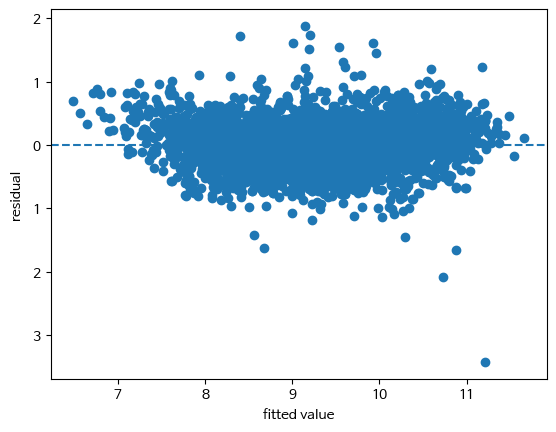

In [ ]:
#잔차 산점도 확인
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value")
plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

잔차의 산점도 그래프로 봤을때, 잔차가 등분산성을 100% 따른다고는 할 수 없지만, 몇 몇 데이터를 제외한 대부분의 데이터들은 등분산성을 따르고 있다고 본다.

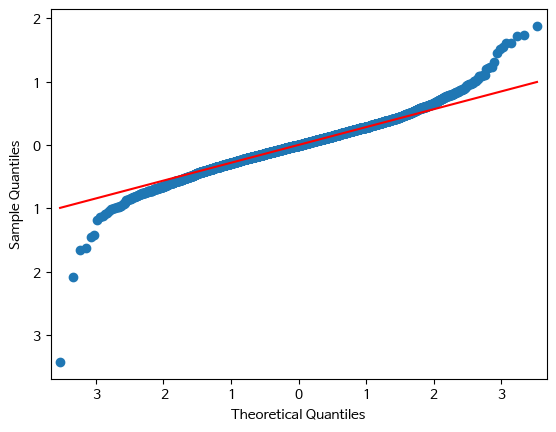

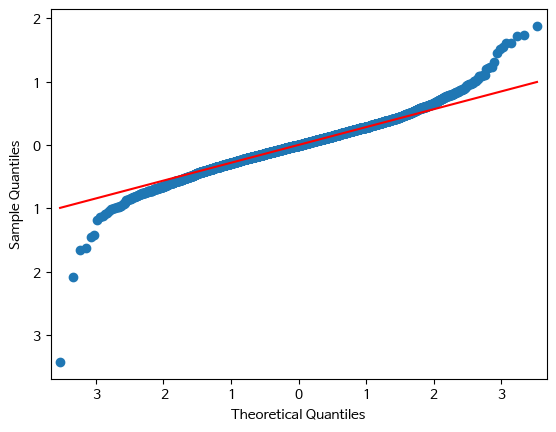

In [ ]:
#잔차 정규성 검정: q-q plot, s-standardized line
qqplot(reg_result.resid, line = "q")

qq-pot으로 봤을때 잔차의 정규성은 현실데이터의 한계로  100% 만족하지 않지만, 대체적으로 데이터들이 정규성을 따르는 것을 볼 수 있다.

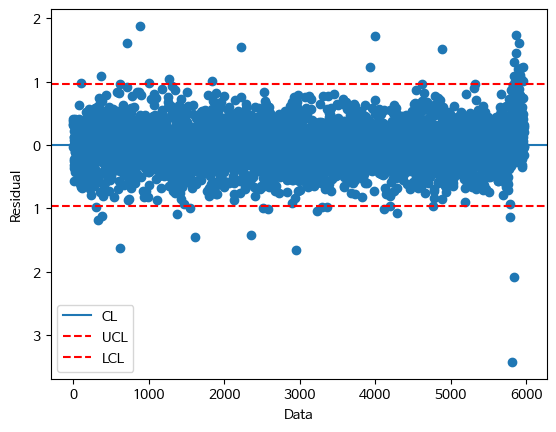

In [ ]:
# 잔차의 독립성 확인
plt.scatter(car_train.index, reg_result.resid)
plt.xlabel("Data")  ;  plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend()

객관적으로는 잔차의 독립성을 만족하진 않지만 , 현실데이터의 한계로 모든 데이터가 잔차의 독립성을 만족할 수 없다고 판단한다. 그래도 이정도는 대체적으로 잔차의 독립성을 만족한다고 생각한다.

In [ ]:
# 평가용 데이터에 대한 성능 확인
train_pred = reg_result.predict(car_train)
test_pred = reg_result.predict(car_test)
print("train data의 결정계수:", r2_score(car_train['log_price'], train_pred))
print("test data의 결정계수:", r2_score(car_test['log_price'], test_pred))

train data의 결정계수: 0.8625454688797649
test data의 결정계수: 0.8445129273050538


In [ ]:
from sklearn.metrics import mean_squared_error

# 훈련 데이터와 테스트 데이터에 대한 예측값 계산
train_pred = reg_result.predict(car_train)
test_pred = reg_result.predict(car_test)

# 훈련 데이터와 테스트 데이터에 대한 MSE 계산
train_mse = mean_squared_error(car_train['log_price'], train_pred)
test_mse = mean_squared_error(car_test['log_price'], test_pred)

print("train data의 MSE:", train_mse)
print("test data의 MSE:", test_mse)


train data의 MSE: 0.10336908522643969
test data의 MSE: 0.12090499192535735


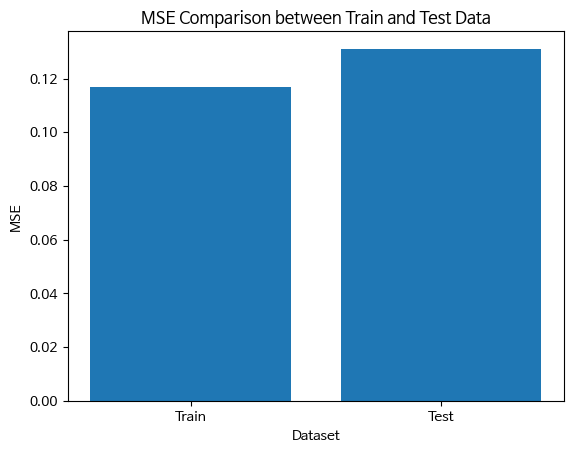

In [ ]:
# 그래프 그리기
plt.bar(['Train', 'Test'], [train_mse, test_mse])
plt.xlabel('Dataset')
plt.ylabel('MSE')
plt.title('MSE Comparison between Train and Test Data')
plt.show()

<h2> 다중선형회귀 결론</h2>


다중선형회귀 의 최종 성능:  
- train : 0.862
- test : 0.844


MSE값:
- train : 0.103
- test : 0.120


최종 모형에 사용된 변수:

- Kilometers_Driven
- Fuel_Type  
- Transmission  
- Seats
- Vehicle_Age
- city_location
-  Power_log
- engine_group
- Owner_Type


최종 회귀식:

Price = 5.42 -0.2Fuel_Type +0.34Transmission-0.05Owner_Type-0.02Seats-0.11Vehicle_Age+0.06city_location+0.97Power_log+0.17engine_group


중고차 가격 예측에 대해  최대출력(power)이 가장 큰 영향을 끼친다.
두번째로 중고차 가격에 영향을 주는 변수는 자동차 변속기의 종류에 따라 예측에 영향을 준다고 추정할 수 있다.